# sklearn model with tensorflow keras tuner

In [1]:
import sklearn
print(sklearn.__version__)

1.2.2


In [2]:
import re
import pandas as pd
import nltk
from nltk.sentiment import SentimentIntensityAnalyzer
from sklearn.feature_extraction.text import TfidfVectorizer
from tqdm import tqdm
from textstat import flesch_reading_ease, gunning_fog
import numpy as np

# nltk.download('punkt')
# nltk.download('averaged_perceptron_tagger')
# nltk.download('stopwords')
# nltk.download('vader_lexicon')

def extract_and_aggregate_features(df, text_column):
    """Extracts and aggregates features at the paragraph, sentence, and word levels."""
    # Processing text into paragraphs, sentences, and words
    df['paragraph_lengths'] = df[text_column].apply(lambda x: [len(p.split()) for p in x.split('\n\n') if p.strip()])
    df['sentence_lengths'] = df[text_column].apply(lambda x: [len(s.split()) for s in nltk.sent_tokenize(x)])
    df['word_lengths'] = df[text_column].apply(lambda x: [len(w) for w in x.split()])

    # Aggregating features
    df['paragraph_count'] = df['paragraph_lengths'].apply(len)
    df['sentence_count'] = df['sentence_lengths'].apply(len)
    df['word_count'] = df['word_lengths'].apply(len)

    df['avg_paragraph_length'] = df['paragraph_lengths'].apply(np.mean)
    df['max_paragraph_length'] = df['paragraph_lengths'].apply(max)
    df['min_paragraph_length'] = df['paragraph_lengths'].apply(min)

    df['avg_sentence_length'] = df['sentence_lengths'].apply(np.mean)
    df['max_sentence_length'] = df['sentence_lengths'].apply(max)
    df['min_sentence_length'] = df['sentence_lengths'].apply(min)

    df['avg_word_length'] = df['word_lengths'].apply(np.mean)
    df['max_word_length'] = df['word_lengths'].apply(max)
    df['min_word_length'] = df['word_lengths'].apply(min)

    # Cleaning up DataFrame to remove list columns
    df.drop(['paragraph_lengths', 'sentence_lengths', 'word_lengths'], axis=1, inplace=True)

    return df

def compute_readability_and_sentiment(df, text_column):
    """Computes readability scores and sentiment analysis."""
    df['flesch_reading_ease'] = df[text_column].apply(flesch_reading_ease)
    df['gunning_fog_index'] = df[text_column].apply(gunning_fog)
    sia = SentimentIntensityAnalyzer()
    df['sentiment_score'] = df[text_column].apply(lambda x: sia.polarity_scores(x)['compound'])

    return df


def add_text_features(df, text_column):
    """Main function to aggregate all text processing and feature extraction steps."""
    tqdm.pandas(desc="Extracting and aggregating text features")
    df = extract_and_aggregate_features(df, text_column)
    df = compute_readability_and_sentiment(df, text_column)


    
    return df    

In [3]:

import wordninja
from nltk.corpus import words

# Load a set of valid English words from NLTK for verification (if needed)
word_list = set(words.words())

def segment_text(text, word_list=word_list):
    """
    Segments concatenated words using wordninja, verifying segmentation with an NLTK words list.

    Args:
    text (str): A string of concatenated words.
    word_list (set): A set containing valid words.

    Returns:
    str: Segmented text, or the original text if segmentation results in less common words.
    """
    segmented_words = wordninja.split(text)
    segmented_text = ' '.join(segmented_words)

    # Optional: verify if the original text is a valid word and if the segmented version introduces less common words
    if text in word_list and not all(word in word_list for word in segmented_words):
        return text
    else:
        return segmented_text



def apply_segmentation(df_chunk, text_col='clean_text'):
    """
    Applies text segmentation to the specified 'text' column of a DataFrame chunk using wordninja.

    Args:
    df_chunk (pd.DataFrame): DataFrame chunk containing a text column with concatenated words.

    Returns:
    pd.DataFrame: DataFrame chunk with a new column 'segmented_text' containing segmented text.
    """
    df_chunk['clean_text'] = df_chunk[text_col].apply(lambda x: segment_text(x))
    return df_chunk

In [4]:
def clean_text(df, col_name = 'full_text'):
    """
    Preprocesses text for both training and testing datasets. 
    Includes loading embeddings, building vocabularies, cleaning text among other things.
    
    :param summaries_train: DataFrame with the training data
    :param summaries_test: DataFrame with the testing data
    :param glove_path: path to the GloVe embedding
    :param paragram_path: path to the Paragram embedding
    :param wiki_news_path: path to the Wiki News embedding
    
    :return: Preprocessed DataFrame and list of out-of-vocab words
    """
    print("Starting text cleaning process. \n")

    
    # Lowercase all texts

    df['lowered'] = df[col_name].apply(lambda x: x.lower())

    
    
    def clean_spacing(text):
        
        # Remove spaces before punctuation
        text = re.sub(r'\s+([,.!?])', r'\1', text)

        # Ensure there is one space after punctuation
        text = re.sub(r'([,.!?])([^\s])', r'\1 \2', text)

        return text
    

    df['clean_text'] = df['lowered'].apply(lambda x: clean_spacing(x))


        
    punct = "/-'?!.,#$%\'()*+-/:;<=>@[\\]^_`{|}~" + '""“”’' + '∞θ÷α•à−β∅³π‘₹´°£€\×™√²—–&'
    
    punct_mapping = {"‘": "'", "₹": "e", "´": "'", "°": "", "€": "e", "™": "tm", "√": " sqrt ", "×": "x", "²": "2", "—": "-", "–": "-", "’": "'", "_": "-",
                     "`": "'", '“': '"', '”': '"', '“': '"', "£": "e", '∞': 'infinity', 'θ': 'theta', '÷': '/', 'α': 'alpha', '•': '.', 'à': 'a', '−': '-', 
                     'β': 'beta', '∅': '', '³': '3', 'π': 'pi', }

    def clean_special_chars(text, punct, mapping):
        for p in mapping:
            text = text.replace(p, mapping[p])
        for p in punct:
            text = text.replace(p, f' {p} ')
        specials = {'\u200b': ' ', '…': ' ... ', '\ufeff': '', 'करना': '', 'है': ''}  
        for s in specials:
            text = text.replace(s, specials[s])
        return text
    

    df['clean_text'] = df['clean_text'].apply(lambda x: clean_special_chars(x, punct, punct_mapping))

    df['clean_text'] = df['lowered'].apply(lambda x: clean_spacing(x))


    cont_map = {
        "ain't": "am not","aren't": "are not","can't": "cannot","can't've": "cannot have","'cause": "because",  "could've": "could have",
        "couldn't": "could not","couldn't've": "could not have","didn't": "did not","doesn't": "does not","don't": "do not","hadn't": "had not",
        "hadn't've": "had not have","hasn't": "has not",
        "haven't": "have not","he'd": "he would","he'd've": "he would have","he'll": "he will","he'll've": "he will have","he's": "he is",
        "how'd": "how did","how'd'y": "how do you","how'll": "how will","how's": "how is","I'd": "I would","I'd've": "I would have","I'll": "I will",
        "I'll've": "I will have","I'm": "I am","I've": "I have",
        "isn't": "is not","it'd": "it had","it'd've": "it would have","it'll": "it will", "it'll've": "it will have","it's": "it is","let's": "let us",
        "ma'am": "madam","mayn't": "may not",
        "might've": "might have","mightn't": "might not","mightn't've": "might not have","must've": "must have","mustn't": "must not",
        "mustn't've": "must not have","needn't": "need not","needn't've": "need not have","o'clock": "of the clock","oughtn't": "ought not",
        "oughtn't've": "ought not have","shan't": "shall not","sha'n't": "shall not",
        "shan't've": "shall not have","she'd": "she would","she'd've": "she would have","she'll": "she will","she'll've": "she will have","she's": "she is",
        "should've": "should have","shouldn't": "should not","shouldn't've": "should not have","so've": "so have","so's": "so is","that'd": "that would",
        "that'd've": "that would have","that's": "that is","there'd": "there had","there'd've": "there would have","there's": "there is",
        "they'd": "they would","they'd've": "they would have","they'll": "they will","they'll've": "they will have","they're": "they are",
        "they've": "they have","to've": "to have","wasn't": "was not","we'd": "we had",
        "we'd've": "we would have","we'll": "we will","we'll've": "we will have","we're": "we are","we've": "we have",
        "weren't": "were not","what'll": "what will","what'll've": "what will have",
        "what're": "what are","what's": "what is","what've": "what have","when's": "when is","when've": "when have",
        "where'd": "where did","where's": "where is","where've": "where have","who'll": "who will","who'll've": "who will have","who's": "who is",
        "who've": "who have","why's": "why is",
        "why've": "why have","will've": "will have","won't": "will not","won't've": "will not have","would've": "would have","wouldn't": "would not",
        "wouldn't've": "would not have","y'all": "you all","y'alls": "you alls","y'all'd": "you all would",
        "y'all'd've": "you all would have","y'all're": "you all are","y'all've": "you all have","you'd": "you had","you'd've": "you would have",
        "you'll": "you you will","you'll've": "you you will have","you're": "you are",  "you've": "you have"}

    c_re = re.compile('(%s)' % '|'.join(cont_map.keys()))

    def expandContractions(text, c_re=c_re):
        def replace(match):
            return cont_map[match.group(0)]
        return c_re.sub(replace, text)


#     p = inflect.engine()

    def removeHTML(text):
        """
        Remove HTML tags from a given text string using regex.
    
        Args:
            text (str): The input text string containing HTML tags.
    
        Returns:
            str: The text string with HTML tags removed.
        """
        html = re.compile(r'<.*?>')
        return html.sub('', text)

    def dataPreprocessing(text):
        """
        Process the input text to perform a series of cleaning and formatting tasks,
        including converting numbers to words, removing specific patterns and whitespace,
        and stripping unwanted characters.
    
        Args:
            text (str): The input text string to preprocess.
    
        Returns:
            str: The cleaned and formatted text.
        """
        text = text.lower()
        text = removeHTML(text)
        # text = re.sub(r'\d+', lambda match: p.number_to_words(match.group()) + " ", text)  # Add spaces around the number words
        text = re.sub(r'\s+', ' ', text)  # Normalize multiple spaces to a single space
        text = re.sub(r"@\w+", '', text)
        text = re.sub(r"'\d+", '', text)
        text = re.sub(r"\d+", '', text)
        text = re.sub(r"http\w+", '', text)
        text = re.sub(r"[-_]+", " ", text)  # Replace hyphens and underscores with space
        text = expandContractions(text)
        text = re.sub(r"\.+", ".", text)
        text = re.sub(r"\,+", ",", text)
        text = re.sub(r"[^\w\s]", "", text)  # Remove all non-alphanumeric and non-space characters
        text = re.sub(r"\s+", " ", text)    # Normalize multiple spaces to a single space

        text = text.strip()

        return text

    
    df['clean_text'] = df['clean_text'].apply(lambda x: dataPreprocessing(x))
    
    # Step 8: Generate combined dense vector for each row of text
    
    # df['combined_dense_vector'] = df['clean_text'].apply(lambda x: get_combined_dense_vector(x, embeddings))

    # # Expand the combined dense vector into separate columns
    
    # combined_df = pd.DataFrame(list(df['combined_dense_vector']), 
    #                            columns=[f"dense_vec_{i}" for i in range(df['combined_dense_vector'][0].size)])

    # # Concatenate this new DataFrame with the original DataFrame
    
    # df = pd.concat([df, combined_df], axis=1)

    # # Step 9: Add TF-IDF features to the corrected text
    
    # df.drop(columns=['combined_dense_vector'], inplace=True)
    
    print('Adding Text Features................. \n')
    
    df = add_text_features(df, 'full_text')

    print('Complete................. \n')
    
    return df

In [5]:
import sklearn
print(sklearn.__version__)

1.2.2


In [6]:
laptop = True

if laptop:
    csv_path = '/home/laptop/github/kaggle/scoring/xlnet_hash.csv'

if not laptop:
    csv_path = '/home/jack/github/kaggle/scoring/xlnet_hash.csv'

In [7]:
pd.set_option('display.max_columns', None)

deberta_full = pd.read_csv(csv_path)
deberta_full.drop(columns=['score', 'labels', 'clean_text'], inplace=True)
deberta_full.head()

,essay_id,deberta_prob_0,deberta_prob_1,deberta_prob_2,deberta_prob_3,deberta_prob_4,deberta_prob_5,xlnet_prob_0,xlnet_prob_1,xlnet_prob_2,xlnet_prob_3,xlnet_prob_4,xlnet_prob_5,hash_0,hash_1,hash_2,hash_3,hash_4,hash_5,hash_6,hash_7,hash_8,hash_9,hash_10,hash_11,hash_12,hash_13,hash_14,hash_15,hash_16,hash_17,hash_18,hash_19,hash_20,hash_21,hash_22,hash_23,hash_24,hash_25,hash_26,hash_27,hash_28,hash_29,hash_30,hash_31,hash_32,hash_33,hash_34,hash_35,hash_36,hash_37,hash_38,hash_39,hash_40,hash_41,hash_42,hash_43,hash_44,hash_45,hash_46,hash_47,hash_48,hash_49,hash_50,hash_51,hash_52,hash_53,hash_54,hash_55,hash_56,hash_57,hash_58,hash_59,hash_60,hash_61,hash_62,hash_63,hash_64,hash_65,hash_66,hash_67,hash_68,hash_69,hash_70,hash_71,hash_72,hash_73,hash_74,hash_75,hash_76,hash_77,hash_78,hash_79,hash_80,hash_81,hash_82,hash_83,hash_84,hash_85,hash_86,hash_87,hash_88,hash_89,hash_90,hash_91,hash_92,hash_93,hash_94,hash_95,hash_96,hash_97,hash_98,hash_99,hash_100,hash_101,hash_102,hash_103,hash_104,hash_105,hash_106,hash_107,hash_108,hash_109,hash_110,hash_111,hash_112,hash_113,hash_114,hash_115,hash_116,hash_117,hash_118,hash_119,hash_120,hash_121,hash_122,hash_123,hash_124,hash_125,hash_126,hash_127,hash_128,hash_129,hash_130,hash_131,hash_132,hash_133,hash_134,hash_135,hash_136,hash_137,hash_138,hash_139,hash_140,hash_141,hash_142,hash_143,hash_144,hash_145,hash_146,hash_147,hash_148,hash_149,hash_150,hash_151,hash_152,hash_153,hash_154,hash_155,hash_156,hash_157,hash_158,hash_159,hash_160,hash_161,hash_162,hash_163,hash_164,hash_165,hash_166,hash_167,hash_168,hash_169,hash_170,hash_171,hash_172,hash_173,hash_174,hash_175,hash_176,hash_177,hash_178,hash_179,hash_180,hash_181,hash_182,hash_183,hash_184,hash_185,hash_186,hash_187,hash_188,hash_189,hash_190,hash_191,hash_192,hash_193,hash_194,hash_195,hash_196,hash_197,hash_198,hash_199
0,000fe60,0.015906,0.832160,0.148738,0.002510,0.000311,0.000375,0.136665,0.115104,0.258191,0.112356,0.164195,0.213489,0.071429,0.023810,0.023810,0.000000,0.000000,0.119048,0.000000,0.02381,0.000000,0.047619,0.023810,0.023810,0.023810,0.0,0.119048,0.023810,0.02381,0.000000,0.119048,0.023810,0.000000,0.000000,0.000000,0.023810,0.000000,0.0,0.000000,0.023810,0.000000,0.047619,0.000000,0.000000,0.047619,0.071429,0.047619,0.071429,0.000000,0.142857,0.000000,0.000000,0.190476,0.000000,0.000000,0.023810,0.000000,0.190476,0.047619,0.000000,0.000000,0.000000,0.000000,0.095238,0.000000,0.000000,0.000000,0.095238,0.071429,0.047619,0.000000,0.023810,0.023810,0.119048,0.047619,0.000000,0.000000,0.000000,0.0,0.000000,0.023810,0.023810,0.0,0.000000,0.000000,0.023810,0.023810,0.071429,0.047619,0.285714,0.000000,0.000000,0.000000,0.047619,0.000000,0.000000,0.00000,0.023810,0.119048,0.047619,0.023810,0.023810,0.071429,0.214286,0.023810,0.095238,0.000000,0.261905,0.000000,0.047619,0.023810,0.071429,0.000000,0.02381,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.023810,0.071429,0.285714,0.023810,0.000000,0.000000,0.071429,0.000000,0.000000,0.190476,0.023810,0.000000,0.023810,0.000000,0.023810,0.238095,0.000000,0.047619,0.000000,0.000000,0.000000,0.000000,0.071429,0.000000,0.000000,0.000000,0.000000,0.142857,0.0,0.000000,0.023810,0.071429,0.0,0.023810,0.047619,0.000000,0.095238,0.000000,0.0,0.02381,0.000000,0.000000,0.000000,0.047619,0.190476,0.023810,0.142857,0.000000,0.071429,0.214286,0.023810,0.047619,0.000000,0.000000,0.023810,0.000000,0.000000,0.047619,0.0,0.000000,0.047619,0.000000,0.02381,0.00000,0.000000,0.000000,0.071429,0.000000,0.000000,0.02381,0.000000,0.000000,0.071429,0.142857,0.0,0.047619,0.023810,0.047619,0.047619,0.285714,0.095238,0.000000,0.119048,0.000000,0.000000,0.000000,0.023810,0.190476,0.071429,0.000000,0.02381
1,001ab80,0.001099,0.010704,0.344778,0.631197,0.011407,0.000815,0.132327,0.110495,0.258206,0.115311,0.163469,0.220192,0.014565,0.000000,0.058259,0.000000,0.014565,0.058259,0.189343,0.00000,0.014565,0.029130,0.014565,0.058259,0.000000,0.0,0.029130,0.014565,0.00000,0.014565,0.000

In [8]:
if laptop:
    csv_path = '/home/laptop/github/kaggle/scoring/data/train.csv'

if not laptop:
    csv_path = '/home/jack/github/kaggle/scoring/data/train.csv'

In [9]:
train = pd.read_csv(csv_path)

In [10]:
train = clean_text(train)

train.head()

Starting text cleaning process. 

Adding Text Features................. 

Complete................. 



,essay_id,full_text,score,lowered,clean_text,paragraph_count,sentence_count,word_count,avg_paragraph_length,max_paragraph_length,min_paragraph_length,avg_sentence_length,max_sentence_length,min_sentence_length,avg_word_length,max_word_length,min_word_length,flesch_reading_ease,gunning_fog_index,sentiment_score
0,000d118,Many people have car where they live. The thin...,3,many people have car where they live. the thin...,many people have car where they live the thing...,1,13,498,498.000000,498,498,38.307692,127,7,4.369478,25,1,57.98,17.33,0.9937
1,000fe60,I am a scientist at NASA that is discussing th...,3,i am a scientist at nasa that is discussing th...,i am a scientist at nasa that is discussing th...,5,21,332,66.400000,98,37,15.809524,48,2,4.018072,11,1,87.55,7.48,0.7705
2,001ab80,People always wish they had the same technolog...,4,people always wish they had the same technolog...,people always wish they had the same technolog...,4,24,550,137.500000,199,85,22.916667,46,9,4.574545,15,1,65.15,11.49,-0.9731
3,001bdc0,"We all heard about Venus, the planet without a...",4,"we all heard about venus, the planet without a...",we all heard about venus the planet without al...,5,20,451,90.200000,165,25,22.550000,38,5,4.982262,20,1,58.32,11.91,0.9702
4,002ba53,"Dear, State Senator\n\nThis is a letter to arg...",3,"dear, state senator\n\nthis is a letter to arg...",dear state senator this is a letter to argue i...,6,15,373,62.166667,118,2,24.933333,76,2,4.873995,14,1,54.66,12.64,0.9771


In [11]:
print(deberta_full.shape, train.shape)

(17307, 213) (17307, 20)


In [12]:
# Combine train and deberta_full on essay_id

train = train.merge(deberta_full, on='essay_id')

In [13]:
train.head()

,essay_id,full_text,score,lowered,clean_text,paragraph_count,sentence_count,word_count,avg_paragraph_length,max_paragraph_length,min_paragraph_length,avg_sentence_length,max_sentence_length,min_sentence_length,avg_word_length,max_word_length,min_word_length,flesch_reading_ease,gunning_fog_index,sentiment_score,deberta_prob_0,deberta_prob_1,deberta_prob_2,deberta_prob_3,deberta_prob_4,deberta_prob_5,xlnet_prob_0,xlnet_prob_1,xlnet_prob_2,xlnet_prob_3,xlnet_prob_4,xlnet_prob_5,hash_0,hash_1,hash_2,hash_3,hash_4,hash_5,hash_6,hash_7,hash_8,hash_9,hash_10,hash_11,hash_12,hash_13,hash_14,hash_15,hash_16,hash_17,hash_18,hash_19,hash_20,hash_21,hash_22,hash_23,hash_24,hash_25,hash_26,hash_27,hash_28,hash_29,hash_30,hash_31,hash_32,hash_33,hash_34,hash_35,hash_36,hash_37,hash_38,hash_39,hash_40,hash_41,hash_42,hash_43,hash_44,hash_45,hash_46,hash_47,hash_48,hash_49,hash_50,hash_51,hash_52,hash_53,hash_54,hash_55,hash_56,hash_57,hash_58,hash_59,hash_60,hash_61,hash_62,hash_63,hash_64,hash_65,hash_66,hash_67,hash_68,hash_69,hash_70,hash_71,hash_72,hash_73,hash_74,hash_75,hash_76,hash_77,hash_78,hash_79,hash_80,hash_81,hash_82,hash_83,hash_84,hash_85,hash_86,hash_87,hash_88,hash_89,hash_90,hash_91,hash_92,hash_93,hash_94,hash_95,hash_96,hash_97,hash_98,hash_99,hash_100,hash_101,hash_102,hash_103,hash_104,hash_105,hash_106,hash_107,hash_108,hash_109,hash_110,hash_111,hash_112,hash_113,hash_114,hash_115,hash_116,hash_117,hash_118,hash_119,hash_120,hash_121,hash_122,hash_123,hash_124,hash_125,hash_126,hash_127,hash_128,hash_129,hash_130,hash_131,hash_132,hash_133,hash_134,hash_135,hash_136,hash_137,hash_138,hash_139,hash_140,hash_141,hash_142,hash_143,hash_144,hash_145,hash_146,hash_147,hash_148,hash_149,hash_150,hash_151,hash_152,hash_153,hash_154,hash_155,hash_156,hash_157,hash_158,hash_159,hash_160,hash_161,hash_162,hash_163,hash_164,hash_165,hash_166,hash_167,hash_168,hash_169,hash_170,hash_171,hash_172,hash_173,hash_174,hash_175,hash_176,hash_177,hash_178,hash_179,hash_180,hash_181,hash_182,hash_183,hash_184,hash_185,hash_186,hash_187,hash_188,hash_189,hash_190,hash_191,hash_192,hash_193,hash_194,hash_195,hash_196,hash_197,hash_198,hash_199
0,000d118,Many people have car where they live. The thin...,3,many people have car where they live. the thin...,many people have car where they live the thing...,1,13,498,498.000000,498,498,38.307692,127,7,4.369478,25,1,57.98,17.33,0.9937,0.156896,0.756281,0.079829,0.005163,0.000922,0.000909,0.116983,0.173203,0.157604,0.287849,0.154709,0.109652,0.031439,0.00000,0.047158,0.031439,0.015719,0.015719,0.220070,0.015719,0.031439,0.047158,0.000000,0.078597,0.015719,0.0,0.031439,0.000000,0.000000,0.031439,0.015719,0.000000,0.078597,0.000000,0.015719,0.015719,0.000000,0.00000,0.000000,0.031439,0.015719,0.204351,0.000000,0.015719,0.015719,0.015719,0.062877,0.000000,0.00000,0.094316,0.062877,0.015719,0.078597,0.047158,0.015719,0.000000,0.000000,0.204351,0.047158,0.062877,0.031439,0.031439,0.000000,0.015719,0.078597,0.015719,0.015719,0.015719,0.000000,0.078597,0.000000,0.047158,0.031439,0.047158,0.062877,0.000000,0.000000,0.015719,0.031439,0.0,0.015719,0.015719,0.062877,0.00000,0.047158,0.015719,0.000000,0.047158,0.015719,0.125754,0.000000,0.000000,0.015719,0.015719,0.015719,0.015719,0.078597,0.047158,0.047158,0.015719,0.015719,0.251509,0.000000,0.314386,0.000000,0.141474,0.0,0.345825,0.015719,0.015719,0.015719,0.031439,0.031439,0.00000,0.0,0.015719,0.000000,0.0,0.000000,0.000000,0.000000,0.031439,0.172912,0.125754,0.015719,0.000000,0.000000,0.000000,0.0,0.000000,0.062877,0.031439,0.015719,0.062877,0.110035,0.000000,0.031439,0.000000,0.047158,0.000000,0.000000,0.157193,0.015719,0.078597,0.031439,0.015719,0.000000,0.031439,0.157193,0.047158,0.015719,0.047158,0.078597,0.000000,0.000000,0.000000,0.015719,0.062877,0.000000,0.000000,0.00000,0.000000,0.000000,0.031439,0.062877,0.015719,0.015719,0.000000,0.015719,0.015719,0.330105,0.015719,0.015719,0.031439,0.000000,0.062877,0.015719,0.015719,0.062877,0.0,0.015719,0.0

In [14]:
df = train.copy()

In [15]:
from sklearn.feature_extraction.text import CountVectorizer
import pandas as pd
import dill
import spacy

# Initialize a CountVectorizer with n-gram range from 1 to 3 (unigrams to trigrams)
vectorizer = CountVectorizer(ngram_range=(1, 3), max_features=1000, stop_words='english')

# Initialize and fit the vectorizer
X_ngrams = vectorizer.fit_transform(df['full_text'])
df_ngrams = pd.DataFrame(X_ngrams.toarray(), columns=vectorizer.get_feature_names_out())

# Save the vectorizer
with open('/home/laptop/github/kaggle/scoring/model_data/sklearn/vectorizer.pkl', 'wb') as f:
    dill.dump(vectorizer, f)

# Load the spaCy model
nlp = spacy.load("en_core_web_sm")

# Function to count POS tags
def pos_counts(text):
    doc = nlp(text)
    total_tokens = len(doc)
    pos_counts = doc.count_by(spacy.attrs.POS)
    return {f'pos_{doc.vocab.strings[pos_id]}': count / total_tokens for pos_id, count in pos_counts.items() if total_tokens > 0}

# Function to count Named Entities
def named_entities(text):
    doc = nlp(text)
    total_tokens = len(doc)
    entities = {}
    for ent in doc.ents:
        entities[ent.label_] = entities.get(ent.label_, 0) + 1
    return {f'ner_{label}': count / total_tokens for label, count in entities.items() if total_tokens > 0}

# Function to count Dependency Tags
def dependency_tags(text):
    doc = nlp(text)
    total_tokens = len(doc)
    dep_counts = doc.count_by(spacy.attrs.DEP)
    return {f'dep_{doc.vocab.strings[dep_id]}': count / total_tokens for dep_id, count in dep_counts.items() if total_tokens > 0}

# Define all possible columns
all_pos_cols = [f'pos_{pos}' for pos in nlp.get_pipe("tagger").labels]
all_ent_cols = [f'ner_{ent}' for ent in nlp.get_pipe("ner").labels]
all_dep_cols = [f'dep_{dep}' for dep in nlp.get_pipe("parser").labels]

# Extract POS tags, named entities, and dependency tags
df_pos = df['full_text'].apply(pos_counts).apply(pd.Series).fillna(0)
df_entities = df['full_text'].apply(named_entities).apply(pd.Series).fillna(0)
df_deps = df['full_text'].apply(dependency_tags).apply(pd.Series).fillna(0)

# Ensure all POS, NER, and Dependency columns are present
for col_list, df_features in [(all_pos_cols, df_pos), (all_ent_cols, df_entities), (all_dep_cols, df_deps)]:
    for col in col_list:
        if col not in df_features.columns:
            df_features[col] = 0

# Sort columns for consistency
df_pos = df_pos[sorted(df_pos.columns)]
df_entities = df_entities[sorted(df_entities.columns)]
df_deps = df_deps[sorted(df_deps.columns)]

# Concatenate all feature DataFrames with the original DataFrame
df = pd.concat([df.reset_index(drop=True), df_ngrams.reset_index(drop=True), 
                         df_pos.reset_index(drop=True), df_entities.reset_index(drop=True), 
                         df_deps.reset_index(drop=True)], axis=1)


In [16]:
# import pandas as pd
# import dill
# import spacy
# import re
# from collections import Counter
# from sklearn.decomposition import LatentDirichletAllocation
# from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
# from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
# from sentence_transformers import SentenceTransformer
# from nltk.corpus import stopwords
# from spellchecker import SpellChecker
# import textstat

# # Load spaCy model
# nlp = spacy.load("en_core_web_sm")
# stop_words = set(stopwords.words('english'))
# sentiment_analyzer = SentimentIntensityAnalyzer()
# spell = SpellChecker()
# bert_model = SentenceTransformer('all-MiniLM-L6-v2')

# text_col = 'clean_text'

# # Define feature extraction functions
# def pos_counts(text):
#     doc = nlp(text)
#     pos_counts = doc.count_by(spacy.attrs.POS)
#     return {f'pos_{doc.vocab.strings[pos_id]}': count for pos_id, count in pos_counts.items()}

# def named_entities(text):
#     doc = nlp(text)
#     entities = {ent.label_: ent for ent in doc.ents}
#     return {f'ner_{label}': count for label, count in entities.items()}

# def dependency_tags(text):
#     doc = nlp(text)
#     dep_counts = doc.count_by(spacy.attrs.DEP)
#     return {f'dep_{doc.vocab.strings[dep_id]}': count for dep_id, count in dep_counts.items()}

# def compute_linguistic_features(text):
#     doc = nlp(text)
#     tenses = [token.tag_ for token in doc if token.pos_ == "VERB"]
#     tense_counts = Counter(tenses)
#     most_common_tense = tense_counts.most_common(1)[0][0] if tense_counts else None
#     verb_tense_consistency = tense_counts[most_common_tense] / len(tenses) if tenses else 0
#     passive_count = sum(1 for token in doc if token.dep_ == "nsubjpass")
#     passive_voice_usage = passive_count / len([token for token in doc if token.pos_ == "VERB"]) if doc else 0
#     modal_verbs = {"can", "could", "will", "would", "shall", "should", "may", "might", "must"}
#     modal_count = sum(1 for token in doc if token.lemma_ in modal_verbs)
#     modal_verb_usage = modal_count / len(doc) if doc else 0
#     lexical_diversity = len(set(doc)) / len(doc) if doc else 0
#     dale_chall_readability = textstat.dale_chall_readability_score(text)
#     automated_readability_index = textstat.automated_readability_index(text)
#     coleman_liau_index = textstat.coleman_liau_index(text)
#     conjunction_count = sum(1 for token in doc if token.pos_ in {"CCONJ", "SCONJ"})
#     clause_count = sum(1 for token in doc if token.dep_ in {"csubj", "advcl", "ccomp", "xcomp"})
#     clause_density = clause_count / max(len([token for token in doc if token.dep_ in {"ROOT", "nsubj"}]), 1)
#     return {
#         "verb_tense_consistency": verb_tense_consistency,
#         "passive_voice_usage": passive_voice_usage,
#         "modal_verb_usage": modal_verb_usage,
#         "lexical_diversity": lexical_diversity,
#         "dale_chall_readability": dale_chall_readability,
#         "automated_readability_index": automated_readability_index,
#         "coleman_liau_index": coleman_liau_index,
#         "conjunction_usage": conjunction_count,
#         "clause_density": clause_density
#     }

# def compute_sentiment_features(text):
#     sentiment_scores = sentiment_analyzer.polarity_scores(text)
#     return {
#         "vader_compound": sentiment_scores["compound"],
#         "vader_positive": sentiment_scores["pos"],
#         "vader_negative": sentiment_scores["neg"],
#         "vader_neutral": sentiment_scores["neu"]
#     }

# def extract_bert_embedding(text):
#     embedding = bert_model.encode([text])[0]
#     return {f'bert_dim_{i}': value for i, value in enumerate(embedding)}

# def extract_topic_features(text, lda_model, vectorizer):
#     text_vector = vectorizer.transform([text])
#     topic_distribution = lda_model.transform(text_vector)[0]
#     return {f'topic_{i}': prob for i, prob in enumerate(topic_distribution)}

# def extract_spelling_grammar_errors(text):
#     misspelled = spell.unknown(text.split())
#     return {
#         "spelling_errors": len(misspelled),
#         "grammar_errors": sum(1 for token in nlp(text) if token.dep_ == "pcomp")
#     }

# def compute_advanced_readability_scores(text):
#     return {
#         "linsear_write_formula": textstat.linsear_write_formula(text),
#         "ari_score": textstat.automated_readability_index(text),
#     }

# def apply_feature_extraction(df, lda_model, vectorizer):
#     df_pos = df[text_col].apply(pos_counts).apply(pd.Series).fillna(0)
#     df_entities = df[text_col].apply(named_entities).apply(pd.Series).fillna(0)
#     df_deps = df[text_col].apply(dependency_tags).apply(pd.Series).fillna(0)
#     df_linguistic = df[text_col].apply(compute_linguistic_features).apply(pd.Series)
#     df_sentiment = df[text_col].apply(compute_sentiment_features).apply(pd.Series)
#     df_bert = df[text_col].apply(extract_bert_embedding).apply(pd.Series)
#     df_topics = df[text_col].apply(lambda x: extract_topic_features(x, lda_model, vectorizer)).apply(pd.Series)
#     df_spelling_grammar = df[text_col].apply(extract_spelling_grammar_errors).apply(pd.Series)
#     df_readability = df[text_col].apply(compute_advanced_readability_scores).apply(pd.Series)
#     return pd.concat([df.reset_index(drop=True), df_pos.reset_index(drop=True), 
#                       df_entities.reset_index(drop=True), df_deps.reset_index(drop=True), 
#                       df_linguistic.reset_index(drop=True), df_sentiment.reset_index(drop=True),
#                       df_bert.reset_index(drop=True), df_topics.reset_index(drop=True),
#                       df_spelling_grammar.reset_index(drop=True),
#                       df_readability.reset_index(drop=True)], axis=1)

# # Train LDA topic model
# tf_vectorizer = TfidfVectorizer(max_features=200, stop_words='english')
# tf = tf_vectorizer.fit_transform(df[text_col])
# lda_model = LatentDirichletAllocation(n_components=10, random_state=42)
# lda_model.fit(tf)

# # Apply feature extraction
# df_train_features = apply_feature_extraction(df, lda_model, tf_vectorizer)

# # Save the LDA model and vectorizers
# with open('/home/jack/github/kaggle/scoring/model_data/sklearn/lda_model.pkl', 'wb') as f:
#     dill.dump(lda_model, f)
# with open('/home/jack/github/kaggle/scoring/model_data/sklearn/vectorizer.pkl', 'wb') as f:
#     dill.dump(vectorizer, f)
# with open('/home/jack/github/kaggle/scoring/model_data/sklearn/tf_vectorizer.pkl', 'wb') as f:
#     dill.dump(tf_vectorizer, f)

# # Initialize and fit the CountVectorizer for n-grams
# X_ngrams_train = vectorizer.fit_transform(df[text_col])
# df_ngrams_train = pd.DataFrame(X_ngrams_train.toarray(), columns=vectorizer.get_feature_names_out())

# # Combine all features
# df_train_combined = pd.concat([df_train_features.reset_index(drop=True), df_ngrams_train.reset_index(drop=True)], axis=1)
# df = df_train_combined.copy()


In [17]:
df.head()

,essay_id,full_text,score,lowered,clean_text,paragraph_count,sentence_count,word_count,avg_paragraph_length,max_paragraph_length,min_paragraph_length,avg_sentence_length,max_sentence_length,min_sentence_length,avg_word_length,max_word_length,min_word_length,flesch_reading_ease,gunning_fog_index,sentiment_score,deberta_prob_0,deberta_prob_1,deberta_prob_2,deberta_prob_3,deberta_prob_4,deberta_prob_5,xlnet_prob_0,xlnet_prob_1,xlnet_prob_2,xlnet_prob_3,xlnet_prob_4,xlnet_prob_5,hash_0,hash_1,hash_2,hash_3,hash_4,hash_5,hash_6,hash_7,hash_8,hash_9,hash_10,hash_11,hash_12,hash_13,hash_14,hash_15,hash_16,hash_17,hash_18,hash_19,hash_20,hash_21,hash_22,hash_23,hash_24,hash_25,hash_26,hash_27,hash_28,hash_29,hash_30,hash_31,hash_32,hash_33,hash_34,hash_35,hash_36,hash_37,hash_38,hash_39,hash_40,hash_41,hash_42,hash_43,hash_44,hash_45,hash_46,hash_47,hash_48,hash_49,hash_50,hash_51,hash_52,hash_53,hash_54,hash_55,hash_56,hash_57,hash_58,hash_59,hash_60,hash_61,hash_62,hash_63,hash_64,hash_65,hash_66,hash_67,hash_68,hash_69,hash_70,hash_71,hash_72,hash_73,hash_74,hash_75,hash_76,hash_77,hash_78,hash_79,hash_80,hash_81,hash_82,hash_83,hash_84,hash_85,hash_86,hash_87,hash_88,hash_89,hash_90,hash_91,hash_92,hash_93,hash_94,hash_95,hash_96,hash_97,hash_98,hash_99,hash_100,hash_101,hash_102,hash_103,hash_104,hash_105,hash_106,hash_107,hash_108,hash_109,hash_110,hash_111,hash_112,hash_113,hash_114,hash_115,hash_116,hash_117,hash_118,hash_119,hash_120,hash_121,hash_122,hash_123,hash_124,hash_125,hash_126,hash_127,hash_128,hash_129,hash_130,hash_131,hash_132,hash_133,hash_134,hash_135,hash_136,hash_137,hash_138,hash_139,hash_140,hash_141,hash_142,hash_143,hash_144,hash_145,hash_146,hash_147,hash_148,hash_149,hash_150,hash_151,hash_152,hash_153,hash_154,hash_155,hash_156,hash_157,hash_158,hash_159,hash_160,hash_161,hash_162,hash_163,hash_164,hash_165,hash_166,hash_167,hash_168,hash_169,hash_170,hash_171,hash_172,hash_173,hash_174,hash_175,hash_176,hash_177,hash_178,hash_179,hash_180,hash_181,hash_182,hash_183,hash_184,hash_185,hash_186,hash_187,hash_188,hash_189,hash_190,hash_191,hash_192,hash_193,hash_194,hash_195,hash_196,hash_197,hash_198,hash_199,000,12,1976,1998,2000,2001,25,30,44,50,60,800,800 degrees,800 degrees fahrenheit,90,90 times,90 times greater,97,97 percent,97 percent carbon,ability,able,accident,accidents,according,acid,action,action coding,actually,ad,advanced,advantage,advantages,ago,agree,ahead,air,air pollution,alert,alien,alien monument,aliens,allow,allowed,allows,alot,amazing,america,american,american west,americans,anger,angry,animals,answer,anymore,april,area,areas,aren,argue,argument,article,article says,article states,artifact,ask,aspects,astronomers,atmosphere,atmosphere 97,atmospheric,atmospheric pressure,attention,author,author states,author supports,average,average 800,avoid,aware,away,bad,ban,banned,based,basic,basically,becuase,begin,believe,belive,beneficial,benefit,benefits,best,better,big,bigger,bike,bit,blame,board,boat,bogota,bored,bring,built,bus,buses,butte,butte mesa,buy,buying,called,came,camera,cameras,campaign,candidate,candidates,canidate,car,car drive,car free,car free day,car usage,car use,carbon,carbon dioxide,care,cars,cars coming,cars drive,cars good,cars people,case,cattle,cause,caused,causes,causing,certain,challenge,challenge exploring,challenge exploring venus,challenges,challenging,chance,change,changed,changes,changing,children,china,choice,choose,cities,citizens,city,claim,class,classroom,classroom computer,classroom computer recognize,classrooms,clear,clearly,close,closer,closest,closest planet,clouds,coding,college,college unfair,colombia,columbia,come,comes,coming,common,communication,community,companies,company,compared,completely,computer,computer recognize,computer recognize student,computers,conclusion,conditions,confused,confused bored,congress,continue,control,cool,corrosive,cost,couldn,countries,country,couple,course,covered,cowboy,cowboys,cowboys program,crash,crashes,craters,cre

In [18]:

# # Import necessary libraries
# import pandas as pd
# from itertools import combinations

# # Assuming the DataFrame `df` and `score` are already defined
# # and excluding irrelevant columns

# # Calculate correlations with the target

# cor = df.drop(columns=['essay_id', 'full_text', 'clean_text', 'lowered' ,'processed_docs', 'topics', 'score'], axis=1)

# correlations = cor.corrwith(df['score']).sort_values(ascending=False)



# # Set a correlation threshold or select top N features
# correlation_threshold = 0.3

# top_features = correlations[abs(correlations) > correlation_threshold].index.tolist()

# # Print the most correlated features
# print("Top correlations with the score:")
# print(top_features)

# # Generate interaction terms between pairs of top features
# for feature1, feature2 in combinations(top_features, 2):
#     df[f'interaction_{feature1}_{feature2}'] = df[feature1] * df[feature2]


# # Optional: print the list of created interaction terms
# interaction_terms = [f'interaction_{feature1}_{feature2}' for feature1, feature2 in combinations(top_features, 2)]
# print("Created interaction terms:")
# print(interaction_terms)


# # export top_features to text file

# with open('/home/jack/github/kaggle/scoring/model_data/sklearn/top_corelations.txt', 'w') as f:
#     for item in top_features:
#         f.write("%s\n" % item)


In [19]:
df.head()

,essay_id,full_text,score,lowered,clean_text,paragraph_count,sentence_count,word_count,avg_paragraph_length,max_paragraph_length,min_paragraph_length,avg_sentence_length,max_sentence_length,min_sentence_length,avg_word_length,max_word_length,min_word_length,flesch_reading_ease,gunning_fog_index,sentiment_score,deberta_prob_0,deberta_prob_1,deberta_prob_2,deberta_prob_3,deberta_prob_4,deberta_prob_5,xlnet_prob_0,xlnet_prob_1,xlnet_prob_2,xlnet_prob_3,xlnet_prob_4,xlnet_prob_5,hash_0,hash_1,hash_2,hash_3,hash_4,hash_5,hash_6,hash_7,hash_8,hash_9,hash_10,hash_11,hash_12,hash_13,hash_14,hash_15,hash_16,hash_17,hash_18,hash_19,hash_20,hash_21,hash_22,hash_23,hash_24,hash_25,hash_26,hash_27,hash_28,hash_29,hash_30,hash_31,hash_32,hash_33,hash_34,hash_35,hash_36,hash_37,hash_38,hash_39,hash_40,hash_41,hash_42,hash_43,hash_44,hash_45,hash_46,hash_47,hash_48,hash_49,hash_50,hash_51,hash_52,hash_53,hash_54,hash_55,hash_56,hash_57,hash_58,hash_59,hash_60,hash_61,hash_62,hash_63,hash_64,hash_65,hash_66,hash_67,hash_68,hash_69,hash_70,hash_71,hash_72,hash_73,hash_74,hash_75,hash_76,hash_77,hash_78,hash_79,hash_80,hash_81,hash_82,hash_83,hash_84,hash_85,hash_86,hash_87,hash_88,hash_89,hash_90,hash_91,hash_92,hash_93,hash_94,hash_95,hash_96,hash_97,hash_98,hash_99,hash_100,hash_101,hash_102,hash_103,hash_104,hash_105,hash_106,hash_107,hash_108,hash_109,hash_110,hash_111,hash_112,hash_113,hash_114,hash_115,hash_116,hash_117,hash_118,hash_119,hash_120,hash_121,hash_122,hash_123,hash_124,hash_125,hash_126,hash_127,hash_128,hash_129,hash_130,hash_131,hash_132,hash_133,hash_134,hash_135,hash_136,hash_137,hash_138,hash_139,hash_140,hash_141,hash_142,hash_143,hash_144,hash_145,hash_146,hash_147,hash_148,hash_149,hash_150,hash_151,hash_152,hash_153,hash_154,hash_155,hash_156,hash_157,hash_158,hash_159,hash_160,hash_161,hash_162,hash_163,hash_164,hash_165,hash_166,hash_167,hash_168,hash_169,hash_170,hash_171,hash_172,hash_173,hash_174,hash_175,hash_176,hash_177,hash_178,hash_179,hash_180,hash_181,hash_182,hash_183,hash_184,hash_185,hash_186,hash_187,hash_188,hash_189,hash_190,hash_191,hash_192,hash_193,hash_194,hash_195,hash_196,hash_197,hash_198,hash_199,000,12,1976,1998,2000,2001,25,30,44,50,60,800,800 degrees,800 degrees fahrenheit,90,90 times,90 times greater,97,97 percent,97 percent carbon,ability,able,accident,accidents,according,acid,action,action coding,actually,ad,advanced,advantage,advantages,ago,agree,ahead,air,air pollution,alert,alien,alien monument,aliens,allow,allowed,allows,alot,amazing,america,american,american west,americans,anger,angry,animals,answer,anymore,april,area,areas,aren,argue,argument,article,article says,article states,artifact,ask,aspects,astronomers,atmosphere,atmosphere 97,atmospheric,atmospheric pressure,attention,author,author states,author supports,average,average 800,avoid,aware,away,bad,ban,banned,based,basic,basically,becuase,begin,believe,belive,beneficial,benefit,benefits,best,better,big,bigger,bike,bit,blame,board,boat,bogota,bored,bring,built,bus,buses,butte,butte mesa,buy,buying,called,came,camera,cameras,campaign,candidate,candidates,canidate,car,car drive,car free,car free day,car usage,car use,carbon,carbon dioxide,care,cars,cars coming,cars drive,cars good,cars people,case,cattle,cause,caused,causes,causing,certain,challenge,challenge exploring,challenge exploring venus,challenges,challenging,chance,change,changed,changes,changing,children,china,choice,choose,cities,citizens,city,claim,class,classroom,classroom computer,classroom computer recognize,classrooms,clear,clearly,close,closer,closest,closest planet,clouds,coding,college,college unfair,colombia,columbia,come,comes,coming,common,communication,community,companies,company,compared,completely,computer,computer recognize,computer recognize student,computers,conclusion,conditions,confused,confused bored,congress,continue,control,cool,corrosive,cost,couldn,countries,country,couple,course,covered,cowboy,cowboys,cowboys program,crash,crashes,craters,cre

In [20]:
df.tail()


,essay_id,full_text,score,lowered,clean_text,paragraph_count,sentence_count,word_count,avg_paragraph_length,max_paragraph_length,min_paragraph_length,avg_sentence_length,max_sentence_length,min_sentence_length,avg_word_length,max_word_length,min_word_length,flesch_reading_ease,gunning_fog_index,sentiment_score,deberta_prob_0,deberta_prob_1,deberta_prob_2,deberta_prob_3,deberta_prob_4,deberta_prob_5,xlnet_prob_0,xlnet_prob_1,xlnet_prob_2,xlnet_prob_3,xlnet_prob_4,xlnet_prob_5,hash_0,hash_1,hash_2,hash_3,hash_4,hash_5,hash_6,hash_7,hash_8,hash_9,hash_10,hash_11,hash_12,hash_13,hash_14,hash_15,hash_16,hash_17,hash_18,hash_19,hash_20,hash_21,hash_22,hash_23,hash_24,hash_25,hash_26,hash_27,hash_28,hash_29,hash_30,hash_31,hash_32,hash_33,hash_34,hash_35,hash_36,hash_37,hash_38,hash_39,hash_40,hash_41,hash_42,hash_43,hash_44,hash_45,hash_46,hash_47,hash_48,hash_49,hash_50,hash_51,hash_52,hash_53,hash_54,hash_55,hash_56,hash_57,hash_58,hash_59,hash_60,hash_61,hash_62,hash_63,hash_64,hash_65,hash_66,hash_67,hash_68,hash_69,hash_70,hash_71,hash_72,hash_73,hash_74,hash_75,hash_76,hash_77,hash_78,hash_79,hash_80,hash_81,hash_82,hash_83,hash_84,hash_85,hash_86,hash_87,hash_88,hash_89,hash_90,hash_91,hash_92,hash_93,hash_94,hash_95,hash_96,hash_97,hash_98,hash_99,hash_100,hash_101,hash_102,hash_103,hash_104,hash_105,hash_106,hash_107,hash_108,hash_109,hash_110,hash_111,hash_112,hash_113,hash_114,hash_115,hash_116,hash_117,hash_118,hash_119,hash_120,hash_121,hash_122,hash_123,hash_124,hash_125,hash_126,hash_127,hash_128,hash_129,hash_130,hash_131,hash_132,hash_133,hash_134,hash_135,hash_136,hash_137,hash_138,hash_139,hash_140,hash_141,hash_142,hash_143,hash_144,hash_145,hash_146,hash_147,hash_148,hash_149,hash_150,hash_151,hash_152,hash_153,hash_154,hash_155,hash_156,hash_157,hash_158,hash_159,hash_160,hash_161,hash_162,hash_163,hash_164,hash_165,hash_166,hash_167,hash_168,hash_169,hash_170,hash_171,hash_172,hash_173,hash_174,hash_175,hash_176,hash_177,hash_178,hash_179,hash_180,hash_181,hash_182,hash_183,hash_184,hash_185,hash_186,hash_187,hash_188,hash_189,hash_190,hash_191,hash_192,hash_193,hash_194,hash_195,hash_196,hash_197,hash_198,hash_199,000,12,1976,1998,2000,2001,25,30,44,50,60,800,800 degrees,800 degrees fahrenheit,90,90 times,90 times greater,97,97 percent,97 percent carbon,ability,able,accident,accidents,according,acid,action,action coding,actually,ad,advanced,advantage,advantages,ago,agree,ahead,air,air pollution,alert,alien,alien monument,aliens,allow,allowed,allows,alot,amazing,america,american,american west,americans,anger,angry,animals,answer,anymore,april,area,areas,aren,argue,argument,article,article says,article states,artifact,ask,aspects,astronomers,atmosphere,atmosphere 97,atmospheric,atmospheric pressure,attention,author,author states,author supports,average,average 800,avoid,aware,away,bad,ban,banned,based,basic,basically,becuase,begin,believe,belive,beneficial,benefit,benefits,best,better,big,bigger,bike,bit,blame,board,boat,bogota,bored,bring,built,bus,buses,butte,butte mesa,buy,buying,called,came,camera,cameras,campaign,candidate,candidates,canidate,car,car drive,car free,car free day,car usage,car use,carbon,carbon dioxide,care,cars,cars coming,cars drive,cars good,cars people,case,cattle,cause,caused,causes,causing,certain,challenge,challenge exploring,challenge exploring venus,challenges,challenging,chance,change,changed,changes,changing,children,china,choice,choose,cities,citizens,city,claim,class,classroom,classroom computer,classroom computer recognize,classrooms,clear,clearly,close,closer,closest,closest planet,clouds,coding,college,college unfair,colombia,columbia,come,comes,coming,common,communication,community,companies,company,compared,completely,computer,computer recognize,computer recognize student,computers,conclusion,conditions,confused,confused bored,congress,continue,control,cool,corrosive,cost,couldn,countries,country,couple,course,covered,cowboy,cowboys,cowboys program,crash,crashes,craters,cre

In [32]:
# drop columns with hash in the name

hash_cols = [col for col in deberta_full.columns if 'hash' in col]

df.drop(columns=hash_cols, inplace=True)

import pandas as pd
from sklearn.feature_extraction.text import HashingVectorizer


# Initialize the HashingVectorizer
n_features = 200  # Number of columns in the hashed vector
hashing_vectorizer = HashingVectorizer(n_features=n_features, alternate_sign=False)

# Transform the text column into hash vector features
hashed_features = hashing_vectorizer.transform(df['clean_text'])

# Convert the hashed features to a dense representation for easier manipulation
hashed_features_dense = hashed_features.todense()

# Create new column names based on the number of features
hashed_columns = [f'hash_{i}' for i in range(n_features)]

# Convert dense representation to a dataframe
hashed_df = pd.DataFrame(hashed_features_dense, columns=hashed_columns)

# Concatenate the original dataframe with the hashed dataframe

df = pd.concat([df, hashed_df], axis=1)

In [33]:
train = df.copy()

In [34]:
train.head()

,essay_id,full_text,score,lowered,clean_text,paragraph_count,sentence_count,word_count,avg_paragraph_length,max_paragraph_length,min_paragraph_length,avg_sentence_length,max_sentence_length,min_sentence_length,avg_word_length,max_word_length,min_word_length,flesch_reading_ease,gunning_fog_index,sentiment_score,deberta_prob_0,deberta_prob_1,deberta_prob_2,deberta_prob_3,deberta_prob_4,deberta_prob_5,xlnet_prob_0,xlnet_prob_1,xlnet_prob_2,xlnet_prob_3,xlnet_prob_4,xlnet_prob_5,000,12,1976,1998,2000,2001,25,30,44,50,60,800,800 degrees,800 degrees fahrenheit,90,90 times,90 times greater,97,97 percent,97 percent carbon,ability,able,accident,accidents,according,acid,action,action coding,actually,ad,advanced,advantage,advantages,ago,agree,ahead,air,air pollution,alert,alien,alien monument,aliens,allow,allowed,allows,alot,amazing,america,american,american west,americans,anger,angry,animals,answer,anymore,april,area,areas,aren,argue,argument,article,article says,article states,artifact,ask,aspects,astronomers,atmosphere,atmosphere 97,atmospheric,atmospheric pressure,attention,author,author states,author supports,average,average 800,avoid,aware,away,bad,ban,banned,based,basic,basically,becuase,begin,believe,belive,beneficial,benefit,benefits,best,better,big,bigger,bike,bit,blame,board,boat,bogota,bored,bring,built,bus,buses,butte,butte mesa,buy,buying,called,came,camera,cameras,campaign,candidate,candidates,canidate,car,car drive,car free,car free day,car usage,car use,carbon,carbon dioxide,care,cars,cars coming,cars drive,cars good,cars people,case,cattle,cause,caused,causes,causing,certain,challenge,challenge exploring,challenge exploring venus,challenges,challenging,chance,change,changed,changes,changing,children,china,choice,choose,cities,citizens,city,claim,class,classroom,classroom computer,classroom computer recognize,classrooms,clear,clearly,close,closer,closest,closest planet,clouds,coding,college,college unfair,colombia,columbia,come,comes,coming,common,communication,community,companies,company,compared,completely,computer,computer recognize,computer recognize student,computers,conclusion,conditions,confused,confused bored,congress,continue,control,cool,corrosive,cost,couldn,countries,country,couple,course,covered,cowboy,cowboys,cowboys program,crash,crashes,craters,create,created,created aliens,creating,curiosity,cut,cydonia,danger,dangerous,dangers,dangers presents,day,days,dear,decades,decide,decrease,degrees,degrees fahrenheit,democratic,density,density size,despite,despite dangers,despite dangers presents,detect,developed,development,did,didn,didnt,diesel,different,difficult,dioxide,distance,does,doesn,doesnt,doing,don,don know,don think,dont,dr,dr huang,drive,driveless,driveless cars,driven,driver,driverless,driverless car,driverless cars,driverless cars coming,drivers,driving,driving car,driving cars,earth,earth like,earth like planet,earth twin,earth venus,easier,easily,easy,effect,effective,effective human,elect,elect president,election,election popular,election popular vote,elections,electoral,electoral college,electoral college unfair,electoral vote,electoral votes,electors,electors vote,electronics,emissions,emotion,emotional,emotional expressions,emotions,end,enjoy,enviroment,environment,especially,europe,everyday,evidence,exactly,example,expensive,experience,explain,explains,exploration,explore,explore venus,exploring,exploring venus,expression,expressions,expressions students,extreme,extremely,eyes,face,face just,face mars,faces,facial,facial action,facial action coding,facial expressions,facial muscles,facs,fact,factor,facts,fahrenheit,fails,fair,family,far,fault,favor,fear,features,feel,feel like,feeling,feelings,fewer,figure,finally,fine,fix,focus,food,form,formation,formed,forms,forms life,france,free,free day,friend,friends,fuel,fully,fun,future,games,garvin,gas,gas emissions,gases,germany,gets,getting,given,gives,giving,global,global surveyor,goes,going,gone,good,good idea,good thing,google,got,government,

In [35]:
len(train.columns)

1362

In [36]:
# import gc

# del df_train_final, df, df_ngrams, df_svd, df_pos, df_entities, df_deps, pos_df, ner_df, dep_df, pos_features, ner_features, dep_features

# gc.collect()

In [37]:
# show columns with nan values greater than 0

nan_cols = train.isna().sum()

nan_cols = nan_cols[nan_cols > 0]

nan_cols    


Series([], dtype: int64)

In [38]:
drop_cols = [ 'full_text', 'clean_text', 'lowered', 'min_word_length']   # processed_docs', , 'global_coherence', 'topics'


train_df = train.copy()

train_df.drop(columns=drop_cols, inplace= True)


In [39]:
train_df.head()

,essay_id,score,paragraph_count,sentence_count,word_count,avg_paragraph_length,max_paragraph_length,min_paragraph_length,avg_sentence_length,max_sentence_length,min_sentence_length,avg_word_length,max_word_length,flesch_reading_ease,gunning_fog_index,sentiment_score,deberta_prob_0,deberta_prob_1,deberta_prob_2,deberta_prob_3,deberta_prob_4,deberta_prob_5,xlnet_prob_0,xlnet_prob_1,xlnet_prob_2,xlnet_prob_3,xlnet_prob_4,xlnet_prob_5,000,12,1976,1998,2000,2001,25,30,44,50,60,800,800 degrees,800 degrees fahrenheit,90,90 times,90 times greater,97,97 percent,97 percent carbon,ability,able,accident,accidents,according,acid,action,action coding,actually,ad,advanced,advantage,advantages,ago,agree,ahead,air,air pollution,alert,alien,alien monument,aliens,allow,allowed,allows,alot,amazing,america,american,american west,americans,anger,angry,animals,answer,anymore,april,area,areas,aren,argue,argument,article,article says,article states,artifact,ask,aspects,astronomers,atmosphere,atmosphere 97,atmospheric,atmospheric pressure,attention,author,author states,author supports,average,average 800,avoid,aware,away,bad,ban,banned,based,basic,basically,becuase,begin,believe,belive,beneficial,benefit,benefits,best,better,big,bigger,bike,bit,blame,board,boat,bogota,bored,bring,built,bus,buses,butte,butte mesa,buy,buying,called,came,camera,cameras,campaign,candidate,candidates,canidate,car,car drive,car free,car free day,car usage,car use,carbon,carbon dioxide,care,cars,cars coming,cars drive,cars good,cars people,case,cattle,cause,caused,causes,causing,certain,challenge,challenge exploring,challenge exploring venus,challenges,challenging,chance,change,changed,changes,changing,children,china,choice,choose,cities,citizens,city,claim,class,classroom,classroom computer,classroom computer recognize,classrooms,clear,clearly,close,closer,closest,closest planet,clouds,coding,college,college unfair,colombia,columbia,come,comes,coming,common,communication,community,companies,company,compared,completely,computer,computer recognize,computer recognize student,computers,conclusion,conditions,confused,confused bored,congress,continue,control,cool,corrosive,cost,couldn,countries,country,couple,course,covered,cowboy,cowboys,cowboys program,crash,crashes,craters,create,created,created aliens,creating,curiosity,cut,cydonia,danger,dangerous,dangers,dangers presents,day,days,dear,decades,decide,decrease,degrees,degrees fahrenheit,democratic,density,density size,despite,despite dangers,despite dangers presents,detect,developed,development,did,didn,didnt,diesel,different,difficult,dioxide,distance,does,doesn,doesnt,doing,don,don know,don think,dont,dr,dr huang,drive,driveless,driveless cars,driven,driver,driverless,driverless car,driverless cars,driverless cars coming,drivers,driving,driving car,driving cars,earth,earth like,earth like planet,earth twin,earth venus,easier,easily,easy,effect,effective,effective human,elect,elect president,election,election popular,election popular vote,elections,electoral,electoral college,electoral college unfair,electoral vote,electoral votes,electors,electors vote,electronics,emissions,emotion,emotional,emotional expressions,emotions,end,enjoy,enviroment,environment,especially,europe,everyday,evidence,exactly,example,expensive,experience,explain,explains,exploration,explore,explore venus,exploring,exploring venus,expression,expressions,expressions students,extreme,extremely,eyes,face,face just,face mars,faces,facial,facial action,facial action coding,facial expressions,facial muscles,facs,fact,factor,facts,fahrenheit,fails,fair,family,far,fault,favor,fear,features,feel,feel like,feeling,feelings,fewer,figure,finally,fine,fix,focus,food,form,formation,formed,forms,forms life,france,free,free day,friend,friends,fuel,fully,fun,future,games,garvin,gas,gas emissions,gases,germany,gets,getting,given,gives,giving,global,global surveyor,goes,going,gone,good,good idea,good thing,google,got,government,great,greater,greece,greenhouse,greenhouse ga

In [40]:
from sklearn.model_selection import train_test_split

# Features and target variable
X = train_df.drop('score', axis=1)
y = train_df['score']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)


In [41]:
X_train.head()

,essay_id,paragraph_count,sentence_count,word_count,avg_paragraph_length,max_paragraph_length,min_paragraph_length,avg_sentence_length,max_sentence_length,min_sentence_length,avg_word_length,max_word_length,flesch_reading_ease,gunning_fog_index,sentiment_score,deberta_prob_0,deberta_prob_1,deberta_prob_2,deberta_prob_3,deberta_prob_4,deberta_prob_5,xlnet_prob_0,xlnet_prob_1,xlnet_prob_2,xlnet_prob_3,xlnet_prob_4,xlnet_prob_5,000,12,1976,1998,2000,2001,25,30,44,50,60,800,800 degrees,800 degrees fahrenheit,90,90 times,90 times greater,97,97 percent,97 percent carbon,ability,able,accident,accidents,according,acid,action,action coding,actually,ad,advanced,advantage,advantages,ago,agree,ahead,air,air pollution,alert,alien,alien monument,aliens,allow,allowed,allows,alot,amazing,america,american,american west,americans,anger,angry,animals,answer,anymore,april,area,areas,aren,argue,argument,article,article says,article states,artifact,ask,aspects,astronomers,atmosphere,atmosphere 97,atmospheric,atmospheric pressure,attention,author,author states,author supports,average,average 800,avoid,aware,away,bad,ban,banned,based,basic,basically,becuase,begin,believe,belive,beneficial,benefit,benefits,best,better,big,bigger,bike,bit,blame,board,boat,bogota,bored,bring,built,bus,buses,butte,butte mesa,buy,buying,called,came,camera,cameras,campaign,candidate,candidates,canidate,car,car drive,car free,car free day,car usage,car use,carbon,carbon dioxide,care,cars,cars coming,cars drive,cars good,cars people,case,cattle,cause,caused,causes,causing,certain,challenge,challenge exploring,challenge exploring venus,challenges,challenging,chance,change,changed,changes,changing,children,china,choice,choose,cities,citizens,city,claim,class,classroom,classroom computer,classroom computer recognize,classrooms,clear,clearly,close,closer,closest,closest planet,clouds,coding,college,college unfair,colombia,columbia,come,comes,coming,common,communication,community,companies,company,compared,completely,computer,computer recognize,computer recognize student,computers,conclusion,conditions,confused,confused bored,congress,continue,control,cool,corrosive,cost,couldn,countries,country,couple,course,covered,cowboy,cowboys,cowboys program,crash,crashes,craters,create,created,created aliens,creating,curiosity,cut,cydonia,danger,dangerous,dangers,dangers presents,day,days,dear,decades,decide,decrease,degrees,degrees fahrenheit,democratic,density,density size,despite,despite dangers,despite dangers presents,detect,developed,development,did,didn,didnt,diesel,different,difficult,dioxide,distance,does,doesn,doesnt,doing,don,don know,don think,dont,dr,dr huang,drive,driveless,driveless cars,driven,driver,driverless,driverless car,driverless cars,driverless cars coming,drivers,driving,driving car,driving cars,earth,earth like,earth like planet,earth twin,earth venus,easier,easily,easy,effect,effective,effective human,elect,elect president,election,election popular,election popular vote,elections,electoral,electoral college,electoral college unfair,electoral vote,electoral votes,electors,electors vote,electronics,emissions,emotion,emotional,emotional expressions,emotions,end,enjoy,enviroment,environment,especially,europe,everyday,evidence,exactly,example,expensive,experience,explain,explains,exploration,explore,explore venus,exploring,exploring venus,expression,expressions,expressions students,extreme,extremely,eyes,face,face just,face mars,faces,facial,facial action,facial action coding,facial expressions,facial muscles,facs,fact,factor,facts,fahrenheit,fails,fair,family,far,fault,favor,fear,features,feel,feel like,feeling,feelings,fewer,figure,finally,fine,fix,focus,food,form,formation,formed,forms,forms life,france,free,free day,friend,friends,fuel,fully,fun,future,games,garvin,gas,gas emissions,gases,germany,gets,getting,given,gives,giving,global,global surveyor,goes,going,gone,good,good idea,good thing,google,got,government,great,greater,greece,greenhouse,greenhouse gas,gree

In [44]:
y_train.value_counts()

score
3    4396
2    3306
4    2748
1     876
5     679
6     109
Name: count, dtype: int64

In [45]:
feature_cols = []

for col in X_train.columns:
    if (col != 'essay_id') and (col != 'score'):
        feature_cols.append(col) 

In [46]:
pd.set_option('display.max_columns', None)
feature_cols

['paragraph_count',
 'sentence_count',
 'word_count',
 'avg_paragraph_length',
 'max_paragraph_length',
 'min_paragraph_length',
 'avg_sentence_length',
 'max_sentence_length',
 'min_sentence_length',
 'avg_word_length',
 'max_word_length',
 'flesch_reading_ease',
 'gunning_fog_index',
 'sentiment_score',
 'deberta_prob_0',
 'deberta_prob_1',
 'deberta_prob_2',
 'deberta_prob_3',
 'deberta_prob_4',
 'deberta_prob_5',
 'xlnet_prob_0',
 'xlnet_prob_1',
 'xlnet_prob_2',
 'xlnet_prob_3',
 'xlnet_prob_4',
 'xlnet_prob_5',
 '000',
 '12',
 '1976',
 '1998',
 '2000',
 '2001',
 '25',
 '30',
 '44',
 '50',
 '60',
 '800',
 '800 degrees',
 '800 degrees fahrenheit',
 '90',
 '90 times',
 '90 times greater',
 '97',
 '97 percent',
 '97 percent carbon',
 'ability',
 'able',
 'accident',
 'accidents',
 'according',
 'acid',
 'action',
 'action coding',
 'actually',
 'ad',
 'advanced',
 'advantage',
 'advantages',
 'ago',
 'agree',
 'ahead',
 'air',
 'air pollution',
 'alert',
 'alien',
 'alien monument',


In [47]:
print(f'Number of features: {len(feature_cols)}')

Number of features: 1356


In [49]:
# save the order of the column names to a txt file

with open('/home/laptop/github/kaggle/scoring/model_data/sklearn/feature_cols.txt', 'w') as f:
    for item in feature_cols:
        f.write("%s\n" % item)

In [50]:
import sklearn
print(sklearn.__version__)

1.2.2


In [75]:
import pandas as pd
from sklearn.preprocessing import StandardScaler, MinMaxScaler
import pickle
import numpy as np

# Extract labels from the training and validation datasets
train_labels = y_train
val_labels = y_test

# Extract features for scaling
train_features = X_train[feature_cols] # Subset with only feature columns
val_features = X_test[feature_cols]

# Initialize the scaler
scaler = MinMaxScaler()  # Using StandardScaler for scaling

# Fit the scaler to the training features
scaler.fit(train_features)  # This defines the transformation based on the training data

# Transform training and validation features
train_feats_scaled = scaler.transform(train_features)  # Transforms the training data
val_feats_scaled = scaler.transform(val_features)  # Transforms the validation data

# Reassign the scaled features to the original DataFrames, keeping the same column names
X_train[feature_cols] = train_feats_scaled  # Replace the original features with scaled ones
X_test[feature_cols] = val_feats_scaled

# Save the scaler for later use
with open('/home/laptop/github/kaggle/scoring/model_data/sklearn/sklearn_scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)  # Persist the scaler for future use or reference


In [76]:
# Check if the file has been written correctly and is not empty
import os
scaler_path = '/home/laptop/github/kaggle/scoring/model_data/sklearn/sklearn_scaler.pkl'
if os.path.getsize(scaler_path) > 0:
    print(f"Scaler saved successfully in {scaler_path}.")
else:
    print(f"Failed to save scaler to {scaler_path}. File is empty.")

Scaler saved successfully in /home/laptop/github/kaggle/scoring/model_data/sklearn/sklearn_scaler.pkl.


In [77]:
# Check if the scaler is StandardScaler
if isinstance(scaler, StandardScaler):
    print("The scaler is a StandardScaler.")
elif isinstance(scaler, MinMaxScaler):
    print("The scaler is a MinMaxScaler.")
else:
    print("The scaler is neither StandardScaler nor MinMaxScaler.")

The scaler is a MinMaxScaler.


In [78]:
X_train.head()

,essay_id,paragraph_count,sentence_count,word_count,avg_paragraph_length,max_paragraph_length,min_paragraph_length,avg_sentence_length,max_sentence_length,min_sentence_length,avg_word_length,max_word_length,flesch_reading_ease,gunning_fog_index,sentiment_score,deberta_prob_0,deberta_prob_1,deberta_prob_2,deberta_prob_3,deberta_prob_4,deberta_prob_5,xlnet_prob_0,xlnet_prob_1,xlnet_prob_2,xlnet_prob_3,xlnet_prob_4,xlnet_prob_5,000,12,1976,1998,2000,2001,25,30,44,50,60,800,800 degrees,800 degrees fahrenheit,90,90 times,90 times greater,97,97 percent,97 percent carbon,ability,able,accident,accidents,according,acid,action,action coding,actually,ad,advanced,advantage,advantages,ago,agree,ahead,air,air pollution,alert,alien,alien monument,aliens,allow,allowed,allows,alot,amazing,america,american,american west,americans,anger,angry,animals,answer,anymore,april,area,areas,aren,argue,argument,article,article says,article states,artifact,ask,aspects,astronomers,atmosphere,atmosphere 97,atmospheric,atmospheric pressure,attention,author,author states,author supports,average,average 800,avoid,aware,away,bad,ban,banned,based,basic,basically,becuase,begin,believe,belive,beneficial,benefit,benefits,best,better,big,bigger,bike,bit,blame,board,boat,bogota,bored,bring,built,bus,buses,butte,butte mesa,buy,buying,called,came,camera,cameras,campaign,candidate,candidates,canidate,car,car drive,car free,car free day,car usage,car use,carbon,carbon dioxide,care,cars,cars coming,cars drive,cars good,cars people,case,cattle,cause,caused,causes,causing,certain,challenge,challenge exploring,challenge exploring venus,challenges,challenging,chance,change,changed,changes,changing,children,china,choice,choose,cities,citizens,city,claim,class,classroom,classroom computer,classroom computer recognize,classrooms,clear,clearly,close,closer,closest,closest planet,clouds,coding,college,college unfair,colombia,columbia,come,comes,coming,common,communication,community,companies,company,compared,completely,computer,computer recognize,computer recognize student,computers,conclusion,conditions,confused,confused bored,congress,continue,control,cool,corrosive,cost,couldn,countries,country,couple,course,covered,cowboy,cowboys,cowboys program,crash,crashes,craters,create,created,created aliens,creating,curiosity,cut,cydonia,danger,dangerous,dangers,dangers presents,day,days,dear,decades,decide,decrease,degrees,degrees fahrenheit,democratic,density,density size,despite,despite dangers,despite dangers presents,detect,developed,development,did,didn,didnt,diesel,different,difficult,dioxide,distance,does,doesn,doesnt,doing,don,don know,don think,dont,dr,dr huang,drive,driveless,driveless cars,driven,driver,driverless,driverless car,driverless cars,driverless cars coming,drivers,driving,driving car,driving cars,earth,earth like,earth like planet,earth twin,earth venus,easier,easily,easy,effect,effective,effective human,elect,elect president,election,election popular,election popular vote,elections,electoral,electoral college,electoral college unfair,electoral vote,electoral votes,electors,electors vote,electronics,emissions,emotion,emotional,emotional expressions,emotions,end,enjoy,enviroment,environment,especially,europe,everyday,evidence,exactly,example,expensive,experience,explain,explains,exploration,explore,explore venus,exploring,exploring venus,expression,expressions,expressions students,extreme,extremely,eyes,face,face just,face mars,faces,facial,facial action,facial action coding,facial expressions,facial muscles,facs,fact,factor,facts,fahrenheit,fails,fair,family,far,fault,favor,fear,features,feel,feel like,feeling,feelings,fewer,figure,finally,fine,fix,focus,food,form,formation,formed,forms,forms life,france,free,free day,friend,friends,fuel,fully,fun,future,games,garvin,gas,gas emissions,gases,germany,gets,getting,given,gives,giving,global,global surveyor,goes,going,gone,good,good idea,good thing,google,got,government,great,greater,greece,greenhouse,greenhouse gas,gree

In [79]:
X_train.tail()

,essay_id,paragraph_count,sentence_count,word_count,avg_paragraph_length,max_paragraph_length,min_paragraph_length,avg_sentence_length,max_sentence_length,min_sentence_length,avg_word_length,max_word_length,flesch_reading_ease,gunning_fog_index,sentiment_score,deberta_prob_0,deberta_prob_1,deberta_prob_2,deberta_prob_3,deberta_prob_4,deberta_prob_5,xlnet_prob_0,xlnet_prob_1,xlnet_prob_2,xlnet_prob_3,xlnet_prob_4,xlnet_prob_5,000,12,1976,1998,2000,2001,25,30,44,50,60,800,800 degrees,800 degrees fahrenheit,90,90 times,90 times greater,97,97 percent,97 percent carbon,ability,able,accident,accidents,according,acid,action,action coding,actually,ad,advanced,advantage,advantages,ago,agree,ahead,air,air pollution,alert,alien,alien monument,aliens,allow,allowed,allows,alot,amazing,america,american,american west,americans,anger,angry,animals,answer,anymore,april,area,areas,aren,argue,argument,article,article says,article states,artifact,ask,aspects,astronomers,atmosphere,atmosphere 97,atmospheric,atmospheric pressure,attention,author,author states,author supports,average,average 800,avoid,aware,away,bad,ban,banned,based,basic,basically,becuase,begin,believe,belive,beneficial,benefit,benefits,best,better,big,bigger,bike,bit,blame,board,boat,bogota,bored,bring,built,bus,buses,butte,butte mesa,buy,buying,called,came,camera,cameras,campaign,candidate,candidates,canidate,car,car drive,car free,car free day,car usage,car use,carbon,carbon dioxide,care,cars,cars coming,cars drive,cars good,cars people,case,cattle,cause,caused,causes,causing,certain,challenge,challenge exploring,challenge exploring venus,challenges,challenging,chance,change,changed,changes,changing,children,china,choice,choose,cities,citizens,city,claim,class,classroom,classroom computer,classroom computer recognize,classrooms,clear,clearly,close,closer,closest,closest planet,clouds,coding,college,college unfair,colombia,columbia,come,comes,coming,common,communication,community,companies,company,compared,completely,computer,computer recognize,computer recognize student,computers,conclusion,conditions,confused,confused bored,congress,continue,control,cool,corrosive,cost,couldn,countries,country,couple,course,covered,cowboy,cowboys,cowboys program,crash,crashes,craters,create,created,created aliens,creating,curiosity,cut,cydonia,danger,dangerous,dangers,dangers presents,day,days,dear,decades,decide,decrease,degrees,degrees fahrenheit,democratic,density,density size,despite,despite dangers,despite dangers presents,detect,developed,development,did,didn,didnt,diesel,different,difficult,dioxide,distance,does,doesn,doesnt,doing,don,don know,don think,dont,dr,dr huang,drive,driveless,driveless cars,driven,driver,driverless,driverless car,driverless cars,driverless cars coming,drivers,driving,driving car,driving cars,earth,earth like,earth like planet,earth twin,earth venus,easier,easily,easy,effect,effective,effective human,elect,elect president,election,election popular,election popular vote,elections,electoral,electoral college,electoral college unfair,electoral vote,electoral votes,electors,electors vote,electronics,emissions,emotion,emotional,emotional expressions,emotions,end,enjoy,enviroment,environment,especially,europe,everyday,evidence,exactly,example,expensive,experience,explain,explains,exploration,explore,explore venus,exploring,exploring venus,expression,expressions,expressions students,extreme,extremely,eyes,face,face just,face mars,faces,facial,facial action,facial action coding,facial expressions,facial muscles,facs,fact,factor,facts,fahrenheit,fails,fair,family,far,fault,favor,fear,features,feel,feel like,feeling,feelings,fewer,figure,finally,fine,fix,focus,food,form,formation,formed,forms,forms life,france,free,free day,friend,friends,fuel,fully,fun,future,games,garvin,gas,gas emissions,gases,germany,gets,getting,given,gives,giving,global,global surveyor,goes,going,gone,good,good idea,good thing,google,got,government,great,greater,greece,greenhouse,greenhouse gas,gree

In [80]:
import pandas as pd
from sklearn.utils import resample
from imblearn.over_sampling import SMOTE


# Now, let's apply SMOTE to balance the minority classes up to 1,000 samples
X = X_train.drop(columns=['essay_id'])
y = train_labels

# Create SMOTE instance to ensure all classes have 1,000 samples
smote = SMOTE(sampling_strategy='not majority', random_state=42)

X_resampled, y_resampled = smote.fit_resample(X, y)

# Create the resampled DataFrame
df_resampled = pd.DataFrame(X_resampled, columns=X.columns)
y_train_resampled = y_resampled

# Display the resampled class distribution to confirm the balancing
print("Resampled class distribution:")
print(y_train_resampled.value_counts())


UPSAMPLE = False

if UPSAMPLE:
    
    # Balance only the training DataFrame
    X_train = df_resampled.copy()
    train_labels = y_train_resampled

    
else:
    pass

print(train_labels.value_counts())


Resampled class distribution:
score
2    4396
3    4396
4    4396
1    4396
5    4396
6    4396
Name: count, dtype: int64
score
3    4396
2    3306
4    2748
1     876
5     679
6     109
Name: count, dtype: int64


In [81]:
X_train.head()

,essay_id,paragraph_count,sentence_count,word_count,avg_paragraph_length,max_paragraph_length,min_paragraph_length,avg_sentence_length,max_sentence_length,min_sentence_length,avg_word_length,max_word_length,flesch_reading_ease,gunning_fog_index,sentiment_score,deberta_prob_0,deberta_prob_1,deberta_prob_2,deberta_prob_3,deberta_prob_4,deberta_prob_5,xlnet_prob_0,xlnet_prob_1,xlnet_prob_2,xlnet_prob_3,xlnet_prob_4,xlnet_prob_5,000,12,1976,1998,2000,2001,25,30,44,50,60,800,800 degrees,800 degrees fahrenheit,90,90 times,90 times greater,97,97 percent,97 percent carbon,ability,able,accident,accidents,according,acid,action,action coding,actually,ad,advanced,advantage,advantages,ago,agree,ahead,air,air pollution,alert,alien,alien monument,aliens,allow,allowed,allows,alot,amazing,america,american,american west,americans,anger,angry,animals,answer,anymore,april,area,areas,aren,argue,argument,article,article says,article states,artifact,ask,aspects,astronomers,atmosphere,atmosphere 97,atmospheric,atmospheric pressure,attention,author,author states,author supports,average,average 800,avoid,aware,away,bad,ban,banned,based,basic,basically,becuase,begin,believe,belive,beneficial,benefit,benefits,best,better,big,bigger,bike,bit,blame,board,boat,bogota,bored,bring,built,bus,buses,butte,butte mesa,buy,buying,called,came,camera,cameras,campaign,candidate,candidates,canidate,car,car drive,car free,car free day,car usage,car use,carbon,carbon dioxide,care,cars,cars coming,cars drive,cars good,cars people,case,cattle,cause,caused,causes,causing,certain,challenge,challenge exploring,challenge exploring venus,challenges,challenging,chance,change,changed,changes,changing,children,china,choice,choose,cities,citizens,city,claim,class,classroom,classroom computer,classroom computer recognize,classrooms,clear,clearly,close,closer,closest,closest planet,clouds,coding,college,college unfair,colombia,columbia,come,comes,coming,common,communication,community,companies,company,compared,completely,computer,computer recognize,computer recognize student,computers,conclusion,conditions,confused,confused bored,congress,continue,control,cool,corrosive,cost,couldn,countries,country,couple,course,covered,cowboy,cowboys,cowboys program,crash,crashes,craters,create,created,created aliens,creating,curiosity,cut,cydonia,danger,dangerous,dangers,dangers presents,day,days,dear,decades,decide,decrease,degrees,degrees fahrenheit,democratic,density,density size,despite,despite dangers,despite dangers presents,detect,developed,development,did,didn,didnt,diesel,different,difficult,dioxide,distance,does,doesn,doesnt,doing,don,don know,don think,dont,dr,dr huang,drive,driveless,driveless cars,driven,driver,driverless,driverless car,driverless cars,driverless cars coming,drivers,driving,driving car,driving cars,earth,earth like,earth like planet,earth twin,earth venus,easier,easily,easy,effect,effective,effective human,elect,elect president,election,election popular,election popular vote,elections,electoral,electoral college,electoral college unfair,electoral vote,electoral votes,electors,electors vote,electronics,emissions,emotion,emotional,emotional expressions,emotions,end,enjoy,enviroment,environment,especially,europe,everyday,evidence,exactly,example,expensive,experience,explain,explains,exploration,explore,explore venus,exploring,exploring venus,expression,expressions,expressions students,extreme,extremely,eyes,face,face just,face mars,faces,facial,facial action,facial action coding,facial expressions,facial muscles,facs,fact,factor,facts,fahrenheit,fails,fair,family,far,fault,favor,fear,features,feel,feel like,feeling,feelings,fewer,figure,finally,fine,fix,focus,food,form,formation,formed,forms,forms life,france,free,free day,friend,friends,fuel,fully,fun,future,games,garvin,gas,gas emissions,gases,germany,gets,getting,given,gives,giving,global,global surveyor,goes,going,gone,good,good idea,good thing,google,got,government,great,greater,greece,greenhouse,greenhouse gas,gree

In [82]:
# To convert features and targets to NumPy arrays for ML use

train_features = X_train.drop(columns=['essay_id'], axis=1).values

train_labels = np.array(train_labels.values)

val_features = X_test.drop(columns=['essay_id'], axis=1).values

val_labels = np.array(y_test.values)




print("Features shape:", train_features.shape)
print("Target shape:", train_labels.shape)

print("Features shape:", val_features.shape)
print("Target shape:", val_labels.shape)



#####     Features shape: (3, 1389)


Features shape: (12114, 1356)
Target shape: (12114,)
Features shape: (5193, 1356)
Target shape: (5193,)


In [83]:
from sklearn.metrics import make_scorer, cohen_kappa_score

def quadratic_weighted_kappa_scorer(y_true, y_pred):
    """
    Compute the Quadratic Weighted Kappa (QWK), also known as Cohen's kappa.
    
    Parameters:
    y_true : array-like of shape (n_samples,)
        True labels.
    y_pred : array-liimport keras_tuner
from sklearn import ensemble
from sklearn import datasets
from sklearn import linear_model
from sklearn import metrics
from sklearn import model_selection

def build_model(hp):
  model_type = hp.Choice('model_type', ['random_forest', 'ridge'])
  if model_type == 'random_forest':
    model = ensemble.RandomForestClassifier(
        n_estimators=hp.Int('n_estimators', 10, 50, step=10),
        max_depth=hp.Int('max_depth', 3, 10))
  else:
    model = linear_model.RidgeClassifier(
        alpha=hp.Float('alpha', 1e-3, 1, sampling='log'))
  return model

tuner = keras_tuner.tuners.SklearnTuner(
    oracle=keras_tuner.oracles.BayesianOptimizationOracle(
        objective=keras_tuner.Objective('score', 'max'),
        max_trials=100),
    hypermodel=build_model,
    scoring=metrics.make_scorer(metrics.accuracy_score),
    cv=model_selection.StratifiedKFold(10),
    directory='.',
    project_name='my_project')ke of shape (n_samples,)
        Predicted labels.
    
    Returns:
    score : float
        Quadratic Weighted Kappa score.
    """
    return cohen_kappa_score(y_true, y_pred, weights='quadratic')


In [84]:
# from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
# import keras_tuner as kt

# model_checkpoint = ModelCheckpoint('data/models/best_standard_model_epoch.keras', 
#                                    save_best_only=True, monitor='val_loss', mode='min')

# early_stopping = EarlyStopping(monitor='val_loss', patience=5, 
#                                restore_best_weights=True)

# call_backs = [model_checkpoint, early_stopping]

In [85]:
import keras_tuner
from sklearn import ensemble, linear_model, model_selection, svm
from lightgbm import LGBMClassifier


def build_model(hp):
    """
    Builds a more comprehensive machine learning model based on hyperparameters for multiclass classification.
    
    Parameters:
    hp : HyperParameters
        Hyperparameters for tuning the model.
    
    Returns:
    model : An instance of a Scikit-learn model.
    """
    # Adding 'lightgbm' as a new model type
    model_type = hp.Choice('model_type', ['random_forest',  'gradient_boosting', 'lightgbm'])

    if model_type == 'random_forest':
        model = ensemble.RandomForestClassifier(
            n_estimators=hp.Int('n_estimators', 10, 100, step=10),
            max_depth=hp.Int('max_depth', 3, 20),
            min_samples_split=hp.Int('min_samples_split', 2, 20),
            min_samples_leaf=hp.Int('min_samples_leaf', 1, 10),
            criterion=hp.Choice('criterion', ['gini', 'entropy']),
            class_weight=hp.Choice('class_weight', ['balanced', 'balanced_subsample']),
            max_samples=hp.Float('max_samples', 0.1, 1.0, sampling='log')
        )



    elif model_type == 'gradient_boosting':
        model = ensemble.GradientBoostingClassifier(
            n_estimators=hp.Int('n_estimators', 50, 200, step=50),
            learning_rate=hp.Float('learning_rate', 0.01, 0.2, sampling='log'),
            max_depth=hp.Int('max_depth', 3, 15),
            subsample=hp.Float('subsample', 0.5, 1.0, step=0.1)
        )

    # Adding LightGBM as a new model type
    elif model_type == 'lightgbm':
        model = LGBMClassifier(
            n_estimators=hp.Int('n_estimators', 50, 200, step=50),
            num_leaves=hp.Int('num_leaves', 31, 127, step=16),
            learning_rate=hp.Float('learning_rate', 0.01, 0.2, sampling='log'),
            min_child_samples=hp.Int('min_child_samples', 10, 50, step=10),
            class_weight=hp.Choice('class_weight', ['balanced', 'balanced_sample']),
        )

    return model


# Defining the custom QWK scorer
qwk_scorer = make_scorer(quadratic_weighted_kappa_scorer)

# Tuner configuration
tuner = keras_tuner.tuners.SklearnTuner(
    oracle=keras_tuner.oracles.BayesianOptimizationOracle(
        objective=keras_tuner.Objective('score', 'max'),
        max_trials=10),
    hypermodel=build_model,
    scoring=qwk_scorer,
    cv=model_selection.StratifiedKFold(3),
    directory='.',
    project_name='data/sklearn',
    overwrite=True)

# Starting the search
tuner.search(train_features, train_labels)      # class_weight=class_weights_dict,

# Retrieving the best model
best_model = tuner.get_best_models(num_models=1)[0]


Trial 10 Complete [00h 00m 04s]
score: 0.8319056847442726

Best score So Far: 0.8646253148706152
Total elapsed time: 00h 37m 09s


In [86]:
full_train = np.concatenate((train_features, val_features), axis=0)

full_labels = np.concatenate((train_labels, val_labels), axis=0)

In [99]:
full_train.shape, full_labels.shape

((17307, 1356), (17307,))

In [87]:
best_model.fit(full_train, full_labels)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.032059 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 85016
[LightGBM] [Info] Number of data points in the train set: 17307, number of used features: 1307
[LightGBM] [Info] Start training from score -1.791759
[LightGBM] [Info] Start training from score -1.791759
[LightGBM] [Info] Start training from score -1.791759
[LightGBM] [Info] Start training from score -1.791760
[LightGBM] [Info] Start training from score -1.791760
[LightGBM] [Info] Start training from score -1.791759
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


LGBMClassifier(class_weight='balanced', learning_rate=0.03996986892406373,
               min_child_samples=10, n_estimators=70, num_leaves=95)

In [88]:
predictions = best_model.predict(val_features)

y_true = val_labels

# predictions = target_scaler.inverse_transform(predictions.reshape(-1, 1)).flatten()


In [89]:
# confusion matrix

from sklearn.metrics import confusion_matrix

confusion_matrix(y_true, predictions)

array([[ 376,    0,    0,    0,    0,    0],
       [   6, 1375,   31,    5,    0,    0],
       [   5,   81, 1694,   96,    8,    0],
       [   0,    0,   14, 1162,    2,    0],
       [   0,    0,    0,    0,  291,    0],
       [   0,    0,    0,    0,    0,   47]])

In [90]:
# classification report

from sklearn.metrics import classification_report

print(classification_report(y_true, predictions))

              precision    recall  f1-score   support

           1       0.97      1.00      0.99       376
           2       0.94      0.97      0.96      1417
           3       0.97      0.90      0.94      1884
           4       0.92      0.99      0.95      1178
           5       0.97      1.00      0.98       291
           6       1.00      1.00      1.00        47

    accuracy                           0.95      5193
   macro avg       0.96      0.98      0.97      5193
weighted avg       0.95      0.95      0.95      5193



In [91]:
# cohens kappa

from sklearn.metrics import cohen_kappa_score

cohen = cohen_kappa_score(y_true, predictions)

In [92]:
# quadratic weighted kappa

from sklearn.metrics import cohen_kappa_score

quadratic = cohen_kappa_score(y_true, predictions, weights='quadratic')

print(f"Cohen's Kappa: {cohen}")
print(f"Quadratic Weighted Kappa: {quadratic}")

Cohen's Kappa: 0.9352984810869999
Quadratic Weighted Kappa: 0.9738683788999247


In [94]:
from joblib import dump, load

if UPSAMPLE:
    
    dump(best_model, '/home/laptop/github/kaggle/scoring/model_data/sklearn/upsampled_random_forest.joblib')

else:
    
    dump(best_model, '/home/laptop/github/kaggle/scoring/model_data/sklearn/standard_random_forest.joblib') 

In [95]:
# forest_model = load('random_forest.joblib') 

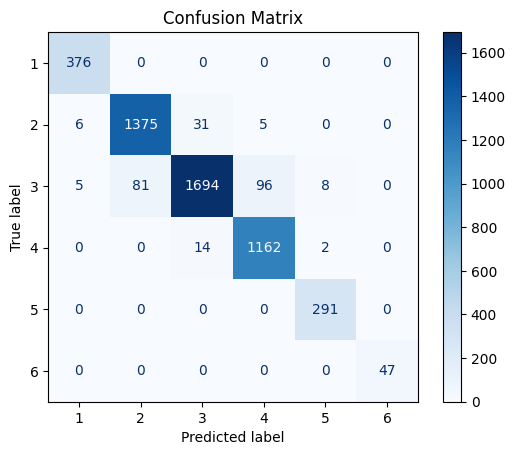

In [96]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Generate and display the confusion matrix for the test predictions
cm = confusion_matrix(y_true, predictions, labels=best_model.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=best_model.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()


In [ ]:
# Identifying misclassified samples
misclassified_indices = (y_true != predictions)
misclassified_samples = val_features[misclassified_indices]
misclassified_true_labels = y_true[misclassified_indices]
misclassified_predicted_labels = predictions[misclassified_indices]


In [ ]:
# Examining features of misclassified samples
import pandas as pd
misclassified_df = pd.DataFrame(misclassified_samples)
misclassified_df['True_Label'] = misclassified_true_labels
misclassified_df['Predicted_Label'] = misclassified_predicted_labels
# Display the first few rows of the misclassified samples
misclassified_df.head()

In [ ]:
# # Feature importance from LightGBM
# feature_importance = best_model.feature_importance(importance_type='gain')
# feature_names = val_features.columns
# feature_importance_df = pd.DataFrame({
#     'Feature': feature_names,
#     'Importance': feature_importance
# })
# # Sort features by importance
# feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)
# print(feature_importance_df)


In [ ]:
# Checking class distribution in the true labels
label_counts = pd.Series(y_true).value_counts()
print(label_counts)


In [ ]:
# from sklearn.model_selection import GridSearchCV
# # Define the hyperparameters to tune
# param_grid = {
#     'learning_rate': [0.01, 0.05, 0.1],
#     'num_leaves': [31, 62, 128],
#     'n_estimators': [50, 100, 200]
# }
# grid_search = GridSearchCV(best_model, param_grid, scoring='', cv=5)
# grid_search.fit(val_features, val_labels)
# print("Best parameters:", grid_search.best_params_)


In [ ]:
# Check LightGBM version
import lightgbm as lgb
print(lgb.__version__)


In [ ]:
# # Ensure the model is fitted
# if not hasattr(best_model, 'feature_importance_'):
#     best_model.fit(val_features, val_labels)  # Train or re-train the model

# # Retrieve feature importance
# feature_importance = best_model.feature_importance_  # Underscore at the end
# feature_names = val_features.columns

# # Create DataFrame for feature importance
# feature_importance_df = pd.DataFrame({
#     'Feature': feature_names,
#     'Importance': feature_importance
# })
# feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# print(feature_importance_df)


In [ ]:
# Assuming `df` is the original DataFrame and `predictions` is a list/array of predicted labels
# If there's a subset used for predictions, ensure it aligns with the DataFrame
val_df['Predicted_Label'] = predictions


In [ ]:
print(len(val_features), len(val_df), len(predictions))

In [ ]:
val_df.tail()

In [ ]:
# merge 'clean_text' column back with val df 

text = val_essays[['essay_id', 'clean_text']]

val_df = val_df.merge(text, on = 'essay_id')

val_df.head()

In [ ]:
# Assuming `df` has the original labels in a column named 'True_Label'
misclassified_samples = val_df[val_df['score'] != val_df['Predicted_Label']]

# Display misclassified samples
print(misclassified_samples[['score', 'Predicted_Label', 'clean_text']][:15])


In [ ]:
# Example: Analyze original text of misclassified samples
misclassified_text = misclassified_samples['clean_text']  # Assuming 'Text' is the original text data
print(misclassified_text.head())


In [ ]:
# load tf model
len(misclassified_text)

In [ ]:
# add full mis classified text to a txt file seperated by  '---' and a new line after every 10 words in each essay

with open('misclassified_text.txt', 'w') as f:
    for essay in misclassified_text:
        f.write("%s\n" % essay)
        f.write('---\n')
        


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

# Assuming `df` has your model's features and labels
X = val_df[feature_cols]
y = val_df['score'] == val_df['Predicted_Label']

# Splitting the dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Fit a RandomForest to see feature importances
clf = RandomForestClassifier(random_state=42)
clf.fit(X_train, y_train)

# Get the most important features
importances = clf.feature_importances_
features = feature_cols
important_features = {features[i]: importances[i] for i in range(len(features))}

# convert to percentages rounded and sort

important_features = {k: round(v, 5) for k, v in important_features.items()}

print("Most predictive features of misclassification:", sorted(important_features.items(), key=lambda x: x[1], reverse=True))

In [ ]:
# import pandas as pd
# import seaborn as sns
# import matplotlib.pyplot as plt

# # Assume val_df and feature_cols are already defined

# # Set the option to display all rows
# pd.set_option('display.max_rows', None)

# # Selecting the features and the target
# X = val_df[feature_cols]
# y = val_df['score']

# # Calculate the correlation between features and the target
# corr = X.corrwith(y)

# # Sort the correlation values
# corr = corr.sort_values(ascending=False)

# # Convert the Series to a DataFrame for heatmap compatibility
# corr_df = pd.DataFrame(corr, columns=['Correlation'])

# corr_df


In [ ]:
# from sklearn.model_selection import train_test_split
# from sklearn.ensemble import RandomForestClassifier
# from sklearn.metrics import classification_report

# # Define the feature set with and without the specific features
# X_with = val_df[feature_cols]  # including all features
# X_without = val_df.drop(columns=['misspelling_count', 'sentence_length'], axis=1) # excluding problematic features

# y = val_df['score']  # target variable

# # Split the data
# X_train_with, X_test_with, y_train, y_test = train_test_split(X_with, y, test_size=0.3, random_state=42)
# X_train_without, X_test_without, _ , _ = train_test_split(X_without, y, test_size=0.3, random_state=42)

# # Train models
# model_with = RandomForestClassifier().fit(X_train_with, y_train)
# model_without = RandomForestClassifier().fit(X_train_without, y_train)

# # Evaluate models
# print("With features:")
# print(classification_report(y_test, model_with.predict(X_test_with)))

# print("Without features:")
# print(classification_report(y_test, model_without.predict(X_test_without)))
